Import libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import re

In [3]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [5]:
from sklearn.utils.class_weight import compute_sample_weight

In [6]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import GridSearchCV

In [54]:
from sklearn.model_selection import StratifiedGroupKFold

In [7]:
np.random.seed(3)

## Data Preparation

#### Exploratory Data Analysis

In [8]:
holc = pd.read_csv('seattle_tracts_holc.csv')
holc.head(5)

,GEOID,pct_holc_A,pct_holc_B,pct_holc_C,pct_holc_D,pct_holc_graded,holc_dominant_grade,holc_grade_score
0,53033005304,0.00000,4.483842e-01,0.000000,0.000000,0.448384,B,2.000000
1,53033005901,0.00000,1.365832e-01,0.284780,0.000000,0.421364,C,2.675854
2,53033005401,0.00000,3.948537e-07,0.030135,0.131897,0.162032,D,3.814013
3,53033010102,0.03148,1.978415e-01,0.171302,0.000000,0.400623,B,2.349012
4,53033000602,0.00000,0.000000e+00,0.000000,0.000000,0.000000,ungraded,NaN


In [9]:
holc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GEOID                181 non-null    int64  
 1   pct_holc_A           181 non-null    float64
 2   pct_holc_B           181 non-null    float64
 3   pct_holc_C           181 non-null    float64
 4   pct_holc_D           181 non-null    float64
 5   pct_holc_graded      181 non-null    float64
 6   holc_dominant_grade  181 non-null    object 
 7   holc_grade_score     141 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 11.4+ KB


In [10]:
print("holc duplicates:", holc.duplicated().sum())

holc duplicates: 0


In [11]:
parcels = pd.read_csv('seattle_parcels_with_tract.csv', low_memory = False)
parcels.head(5)

,Major,Minor,CurrentZoning,SqFtLot,NbrLivingUnits,ZipCode,Stories,BldgGrade,SqFtTotLiving,SqFtGarageAttached,Bedrooms,BathFullCount,YrBuilt,YrRenovated,Condition,ApprLandVal,ApprImpsVal,TaxableLandVal,TaxableImpsVal,GEOID
0,982870,2753,LR3 (M1),500,1.0,98122,3.0,8.0,1080.0,0.0,2.0,2.0,2021.0,0.0,3.0,340000.0,280000.0,340000.0,280000.0,53033007700
1,57900,1110,NR3,6322,1.0,98117,1.0,8.0,2320.0,230.0,3.0,1.0,1954.0,0.0,3.0,615000.0,390000.0,615000.0,390000.0,53033001600
2,287710,4110,NC2-55 (M),3960,1.0,98103,1.5,7.0,1780.0,0.0,4.0,1.0,1925.0,0.0,3.0,0.0,300.0,0.0,0.0,53033002900
3,287710,4110,NC2-55 (M),3960,1.0,98103,1.5,7.0,1780.0,0.0,4.0,1.0,1925.0,0.0,3.0,1279000.0,700.0,376000.0,128900.0,53033002900
4,390410,230,NR3,6750,1.0,98118,1.0,6.0,660.0,0.0,2.0,1.0,1918.0,0.0,3.0,308000.0,150000.0,308000.0,150000.0,53033011101


In [12]:
print("parcels duplicates:", parcels.duplicated().sum())

parcels duplicates: 181


In [13]:
parcels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193074 entries, 0 to 193073
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Major               193074 non-null  int64  
 1   Minor               193074 non-null  int64  
 2   CurrentZoning       193074 non-null  object 
 3   SqFtLot             193074 non-null  int64  
 4   NbrLivingUnits      163499 non-null  float64
 5   ZipCode             147720 non-null  object 
 6   Stories             163499 non-null  float64
 7   BldgGrade           163499 non-null  float64
 8   SqFtTotLiving       163499 non-null  float64
 9   SqFtGarageAttached  163499 non-null  float64
 10  Bedrooms            163499 non-null  float64
 11  BathFullCount       163499 non-null  float64
 12  YrBuilt             163499 non-null  float64
 13  YrRenovated         163499 non-null  float64
 14  Condition           163499 non-null  float64
 15  ApprLandVal         189567 non-nul

In [14]:
parcels[parcels.duplicated(keep=False)].head()

,Major,Minor,CurrentZoning,SqFtLot,NbrLivingUnits,ZipCode,Stories,BldgGrade,SqFtTotLiving,SqFtGarageAttached,Bedrooms,BathFullCount,YrBuilt,YrRenovated,Condition,ApprLandVal,ApprImpsVal,TaxableLandVal,TaxableImpsVal,GEOID
1752,322604,9177,NC3-95 (M),484328,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,53033001201
1753,322604,9177,NC3-95 (M),484328,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,53033001201
3430,927620,200,LR3 (M2),6225,1.0,NaN,3.0,9.0,1200.0,0.0,3.0,0.0,2025.0,0.0,3.0,897000.0,1325000.0,897000.0,1325000.0,53033009801
3432,927620,200,LR3 (M2),6225,1.0,NaN,3.0,9.0,1200.0,0.0,3.0,0.0,2025.0,0.0,3.0,897000.0,1325000.0,897000.0,1325000.0,53033009801
3434,927620,200,LR3 (M2),6225,1.0,NaN,2.0,9.0,1200.0,0.0,3.0,0.0,2025.0,0.0,3.0,897000.0,1325000.0,897000.0,1325000.0,53033009801


In [16]:
parcels.groupby(['Major', 'Minor'])['GEOID'].nunique().max()

1

In [17]:
parcels.duplicated(subset=['Major', 'Minor']).sum()

np.int64(4082)

In [19]:
parcels = parcels.drop_duplicates()
parcels.info()

<class 'pandas.core.frame.DataFrame'>
Index: 192893 entries, 0 to 193073
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Major               192893 non-null  int64  
 1   Minor               192893 non-null  int64  
 2   CurrentZoning       192893 non-null  object 
 3   SqFtLot             192893 non-null  int64  
 4   NbrLivingUnits      163335 non-null  float64
 5   ZipCode             147636 non-null  object 
 6   Stories             163335 non-null  float64
 7   BldgGrade           163335 non-null  float64
 8   SqFtTotLiving       163335 non-null  float64
 9   SqFtGarageAttached  163335 non-null  float64
 10  Bedrooms            163335 non-null  float64
 11  BathFullCount       163335 non-null  float64
 12  YrBuilt             163335 non-null  float64
 13  YrRenovated         163335 non-null  float64
 14  Condition           163335 non-null  float64
 15  ApprLandVal         189386 non-null  fl

In [20]:
print("parcels duplicates:", parcels.duplicated().sum())

parcels duplicates: 0


In [21]:
acs = pd.read_csv('acs_tract_clean.csv')
acs.head(5)

,tractID,Median household income in the past 12 months (in 2024 inflation-adjusted dollars),Total:_x,Owner occupied,Renter occupied,Total:_y,White alone,Black or African American alone,American Indian and Alaska Native alone,Asian alone,...,pct_black,pct_asian,pct_amer_indian,pct_pacific_isl,pct_other_race,pct_two_plus_race,pct_renter_cost_burdened,pct_renter_severely_burdened,TRACTCE,GEOID
0,1.01,69577.0,1746,141,1605,3417,1693,652,0,422,...,0.190811,0.123500,0.000000,0.000000,0.038338,0.151888,0.443614,0.183178,101,53033000101
1,1.02,89840.0,2358,840,1518,4321,3121,362,0,431,...,0.083777,0.099745,0.000000,0.000000,0.052303,0.041888,0.563900,0.210804,102,53033000102
2,2.01,88833.0,2486,1269,1217,4953,2594,356,41,980,...,0.071876,0.197860,0.008278,0.000000,0.123360,0.074904,0.589154,0.171734,201,53033000201
3,2.02,138472.0,1549,1131,418,4404,2165,374,6,708,...,0.084923,0.160763,0.001362,0.000000,0.077203,0.184151,0.456938,0.358852,202,53033000202
4,3.00,135536.0,1201,865,336,2926,1797,179,11,612,...,0.061176,0.209159,0.003759,0.000342,0.007861,0.103554,0.324405,0.122024,300,53033000300


In [22]:
print("acs duplicates:", acs.duplicated().sum())

acs duplicates: 0


In [23]:
df = pd.merge(parcels, acs, on = 'GEOID', how = 'left')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192893 entries, 0 to 192892
Data columns (total 59 columns):
 #   Column                                                                              Non-Null Count   Dtype  
---  ------                                                                              --------------   -----  
 0   Major                                                                               192893 non-null  int64  
 1   Minor                                                                               192893 non-null  int64  
 2   CurrentZoning                                                                       192893 non-null  object 
 3   SqFtLot                                                                             192893 non-null  int64  
 4   NbrLivingUnits                                                                      163335 non-null  float64
 5   ZipCode                                                                             14

In [24]:
print("df duplicates after first merge:", df.duplicated().sum())

df duplicates after first merge: 0


In [25]:
df = pd.merge(df, holc, on = 'GEOID', how = 'left')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192893 entries, 0 to 192892
Data columns (total 66 columns):
 #   Column                                                                              Non-Null Count   Dtype  
---  ------                                                                              --------------   -----  
 0   Major                                                                               192893 non-null  int64  
 1   Minor                                                                               192893 non-null  int64  
 2   CurrentZoning                                                                       192893 non-null  object 
 3   SqFtLot                                                                             192893 non-null  int64  
 4   NbrLivingUnits                                                                      163335 non-null  float64
 5   ZipCode                                                                             14

In [26]:
print("df duplicates after second merge:", df.duplicated().sum())

df duplicates after second merge: 0


In [27]:
# How many of each HOLC grade do we have?
df['holc_dominant_grade'].value_counts()

holc_dominant_grade
B           75008
C           45366
ungraded    34488
D           28101
A            9930
Name: count, dtype: int64

In [28]:
# Drop the ungraded rows since we're comparing current data to HOLC grades
df_grades = df[df['holc_dominant_grade'] != 'ungraded']
df_grades['holc_dominant_grade'].value_counts()

holc_dominant_grade
B    75008
C    45366
D    28101
A     9930
Name: count, dtype: int64

In [31]:
print("df duplicates after drop ungraded:", df_grades.duplicated().sum())

df duplicates after drop ungraded: 0


In [30]:
# print("df duplicates after drop columns:", df_col.duplicated().sum())

df duplicates after drop columns: 4047


All of the confusion matrices for random forest, boosting, and the decision tree were perfect. We think this was because there were duplicate rows after the identifying columns were dropped, and some duplicate rows were in train and some were in test. To fix this, we will split based on GEOID, so that all rows with the same GEOID are in either train or test but not both. After that we will drop the identifying rows.

In [32]:
df_grades['GEOID'].value_counts()

GEOID
53033005600    3020
53033003000    2758
53033003100    2621
53033009900    2493
53033009500    2445
               ... 
53033026500      45
53033005303      25
53033005304       7
53033990100       6
53033026300       4
Name: count, Length: 141, dtype: int64

In [35]:
# Drop all other HOLC columns because of multicollinearity
df_no_holc = df_grades.drop(columns = ['pct_holc_A', 'pct_holc_B', 'pct_holc_C', 'pct_holc_D', 'pct_holc_graded', 'holc_grade_score'])
df_no_holc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158405 entries, 0 to 192891
Data columns (total 60 columns):
 #   Column                                                                              Non-Null Count   Dtype  
---  ------                                                                              --------------   -----  
 0   Major                                                                               158405 non-null  int64  
 1   Minor                                                                               158405 non-null  int64  
 2   CurrentZoning                                                                       158405 non-null  object 
 3   SqFtLot                                                                             158405 non-null  int64  
 4   NbrLivingUnits                                                                      134017 non-null  float64
 5   ZipCode                                                                             120620 

In [36]:
print("df duplicates after drop HOLC columns:", df_no_holc.duplicated().sum())

df duplicates after drop HOLC columns: 0


In [34]:
# How many zip codes do we have?
df_no_holc['ZipCode'].value_counts()

ZipCode
98115         11807
98118         11787
98103         10142
98117          9220
98144          7207
98116          6627
98105          6450
98199          6345
98106          6196
98122          5947
98126          5795
98112          5779
98107          5738
98108          5347
98136          5017
98119          3763
98178          2315
98109          2219
98102          1844
98146           935
98125            93
98134            12
98177             3
98114             2
98104             2
98121             2
90108             1
98136-1728        1
98118-6116        1
sq                1
98018             1
98301             1
3                 1
98015             1
# 2               1
988122            1
98115-7942        1
# 3               1
98000             1
98199-3014        1
91844             1
0                 1
98013             1
98132             1
98103-8173        1
98                1
98118-3167        1
D1 south          1
98107-5353        1
981182019   

In [37]:
# Will dropping ZipCode change the proportion of the HOLC grades?
df_no_holc['holc_dominant_grade'].value_counts(normalize = True)

holc_dominant_grade
B    0.473520
C    0.286392
D    0.177400
A    0.062687
Name: proportion, dtype: float64

In [38]:
df_no_zip = df_no_holc.drop(columns = ['ZipCode'])
df_no_zip['holc_dominant_grade'].value_counts(normalize = True)

holc_dominant_grade
B    0.473520
C    0.286392
D    0.177400
A    0.062687
Name: proportion, dtype: float64

In [39]:
print("df duplicates after drop zip code column:", df_no_zip.duplicated().sum())

df duplicates after drop zip code column: 0


Drop zip code because it has a lot of null values, cleaning would result in even more null values, 
it doesn't change the grade proportions, and geographic location may be too close to HOLC grades.

In [40]:
# Will dropping rows with null values change the proportion of HOLC grades?
df_dropNaN = df_no_zip.dropna()
df_dropNaN['holc_dominant_grade'].value_counts(normalize = True)

holc_dominant_grade
B    0.512663
C    0.283482
D    0.164364
A    0.039491
Name: proportion, dtype: float64

In [41]:
# Compare actual numbers
df_dropNaN['holc_dominant_grade'].value_counts()

holc_dominant_grade
B    66012
C    36502
D    21164
A     5085
Name: count, dtype: int64

Numbers from earlier:   
holc_dominant_grade  
B    75045  
C    45421  
D    28137  
A     9931

Dropping all the rows with null values would change the percentage of the HOLC grades in the data set. 
Instead, create indicator columns for columns with missing values to note whether the value was missing and fill in nulls with an impossible value (-1) as a placeholder.

In [42]:
# Copy dataframe
df_clean = df_no_zip.copy()

In [43]:
for col in df_clean.select_dtypes(include = ['float64']).columns:
    if df_clean[col].isnull().any():
        # Create indicator column (1 = missing, 0 = real value)
        df_clean[f'{col}_is_missing'] = df_clean[col].isnull().astype(int)

        # Fill empty spaces with -1 placeholder
        df_clean[col] = df_clean[col].fillna(-1)

In [44]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158405 entries, 0 to 192891
Data columns (total 86 columns):
 #   Column                                                                                         Non-Null Count   Dtype  
---  ------                                                                                         --------------   -----  
 0   Major                                                                                          158405 non-null  int64  
 1   Minor                                                                                          158405 non-null  int64  
 2   CurrentZoning                                                                                  158405 non-null  object 
 3   SqFtLot                                                                                        158405 non-null  int64  
 4   NbrLivingUnits                                                                                 158405 non-null  float64
 5   Stories       

In [45]:
# Double check for null values
null_counts = df_clean.isnull().sum()
null_counts[null_counts > 0]

Series([], dtype: int64)

In [46]:
print("df duplicates after handle null values:", df_clean.duplicated().sum())

df duplicates after handle null values: 0


In [47]:
# Check zoning before one hot encoding
#pd.set_option('display.max_rows', None)
df_clean['CurrentZoning'].value_counts()

CurrentZoning
NR3                   88754
NR2                   11019
LR2 (M)                9609
LR3 (M)                9350
LR1 (M)                8688
                      ...  
MIO-50-LR1 RC (M)         1
IG1 U/65                  1
SM-RB 125 (M2)            1
MIO-105-NC3-55 (M)        1
MIO-70-NC3-95 (M)         1
Name: count, Length: 243, dtype: int64

The CurrentZoning column needs more cleaning to encode well.  
Create a density column with neighborhood residential (mostly single family homes) = 1, low rise residential buildings = 2, midrise residential buildings = 3, highrise residential buildings = 4, other (mixed use, commercial, industrial) = -1.  
Create is_mixed_use, is_commercial, and is_industrial as one hot encoded columns.

In [48]:
def extract_base(zone):
    if pd.isna(zone):
        return "UNKNOWN"
    
    z = zone.upper()

    # Remove (M), (M1), etc.
    z = re.sub(r"\(.*?\)", "", z)

    # Remove leading/trailing spaces
    z = z.strip()

    # Handle MIO overlays
    if z.startswith("MIO-"):
        parts = z.split("-")
        if len(parts) >= 2:
            z = "-".join(parts[2:]) if parts[1].isdigit() else "-".join(parts[1:])

    # Take first token before space or dash
    z = re.split(r"[ -]", z)[0]

    return z


def map_features(zone):
    base = extract_base(zone)

    # Density
    if base.startswith("NR"):
        density = 1
    elif base.startswith("LR"):
        density = 2
    elif base.startswith("MR"):
        density = 3
    elif base.startswith("HR"):
        density = 4
    else:
        density = -1

    # Mixed-use
    is_mixed_use = int(base.startswith("NC"))

    # Commercial
    is_commercial = int(base.startswith("C") and not base.startswith("NC"))

    # Industrial
    is_industrial = int(base.startswith(("IG","IC","II","IB","UI")))

    return density, is_mixed_use, is_commercial, is_industrial

In [49]:
df_clean[["density", "is_mixed_use", "is_commercial", "is_industrial"]] = (
    df_clean["CurrentZoning"]
    .apply(map_features)
    .apply(pd.Series)
)

In [50]:
df_clean[["CurrentZoning", "density", "is_mixed_use", "is_commercial", "is_industrial"]].head(20)

,CurrentZoning,density,is_mixed_use,is_commercial,is_industrial
0,LR3 (M1),2,0,0,0
2,NC2-55 (M),-1,1,0,0
3,NC2-55 (M),-1,1,0,0
4,NR3,1,0,0,0
5,NR3,1,0,0,0
6,NR3,1,0,0,0
7,LR2 (M),2,0,0,0
8,NC3-75 (M),-1,1,0,0
9,NR3,1,0,0,0
12,LR3 (M),2,0,0,0


In [61]:
# For final dataframe to use for tree based models, drop CurrentZoning
df_clean = df_clean.drop(columns = ['CurrentZoning'])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158405 entries, 0 to 192891
Data columns (total 89 columns):
 #   Column                                                                                         Non-Null Count   Dtype  
---  ------                                                                                         --------------   -----  
 0   Major                                                                                          158405 non-null  int64  
 1   Minor                                                                                          158405 non-null  int64  
 2   SqFtLot                                                                                        158405 non-null  int64  
 3   NbrLivingUnits                                                                                 158405 non-null  float64
 4   Stories                                                                                        158405 non-null  float64
 5   BldgGrade     

In [62]:
print("df duplicates after handle zoning:", df_clean.duplicated().sum())

df duplicates after handle zoning: 0


In [63]:
df_clean['holc_dominant_grade'].value_counts(normalize = True)

holc_dominant_grade
B    0.473520
C    0.286392
D    0.177400
A    0.062687
Name: proportion, dtype: float64

Split data so that all rows with the same GEOID are in either train or test so that train and test don't have duplicate rows and it's approximately an 80/20 split.

In [64]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=3)

for train_idx, test_idx in sgkf.split(
    df_clean,
    df_clean['holc_dominant_grade'],
    groups=df_clean['GEOID']
):
    train = df_clean.iloc[train_idx]
    test = df_clean.iloc[test_idx]
    break  # take the first split (~80/20)

In [65]:
print(len(set(train['GEOID']).intersection(set(test['GEOID']))))

0


Split data and drop identifying columns.

In [66]:
X_train = train.drop(columns=[
    'holc_dominant_grade',
    'Major', 'Minor', 'GEOID', 'tractID', 'TRACTCE'
])

y_train = train['holc_dominant_grade']

X_test = test.drop(columns=[
    'holc_dominant_grade',
    'Major', 'Minor', 'GEOID', 'tractID', 'TRACTCE'
])

y_test = test['holc_dominant_grade']

## Modeling

#### Random Forest model

In [67]:
# Weight the classes since they're not balanced
# Max features cross validate p/3, sqrt(p), p/2
rf = RandomForestClassifier(
    class_weight = 'balanced',
    random_state = 3)

In [68]:
rf.fit(X_train,y_train)

# Predict values
y_pred_rf = rf.predict(X_test)

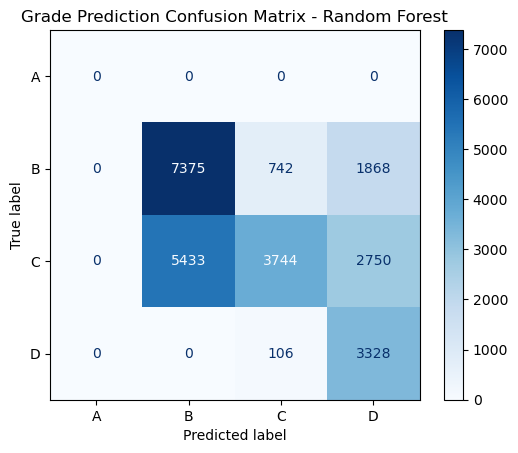

In [70]:
cm = confusion_matrix(y_test, y_pred_rf, labels = rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = rf.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title("Grade Prediction Confusion Matrix - Random Forest")
plt.show()

In [71]:
# create a dataframe of feature importances and their corresponding column names
importances_rf = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf.feature_importances_})
importances_rf = importances_rf.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_rf)

                                              Feature    Importance
0                                           pct_white  8.466982e-02
1                                           pct_black  5.413510e-02
2                              Median value (dollars)  5.345152e-02
3   Median household income in the past 12 months ...  4.905721e-02
4                                              Total:  4.386485e-02
..                                                ...           ...
78                          TaxableLandVal_is_missing  5.811801e-16
79                                      is_commercial  4.540584e-16
80                           SqFtTotLiving_is_missing  3.446772e-16
81                             ApprLandVal_is_missing  3.082250e-16
82                                 YrBuilt_is_missing  3.076062e-16

[83 rows x 2 columns]


#### Boosting

In [72]:
# fit Gradient Boosting model
boost = GradientBoostingClassifier(random_state=3)
training_weights = compute_sample_weight(class_weight = 'balanced', y = y_train)
boost.fit(X_train, y_train, sample_weight = training_weights)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [73]:
# create a dataframe of feature importances and their corresponding column names
importances_boost = pd.DataFrame({'Feature': X_train.columns, 'Importance': boost.feature_importances_})
importances_boost = importances_boost.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_boost)

                                              Feature  Importance
0                                       pct_owner_occ    0.153012
1                                           pct_white    0.144101
2   Median household income in the past 12 months ...    0.095753
3                              Median value (dollars)    0.070354
4                        pct_renter_severely_burdened    0.055939
..                                                ...         ...
78                                Bedrooms_is_missing    0.000000
79                      SqFtGarageAttached_is_missing    0.000000
80                           SqFtTotLiving_is_missing    0.000000
81                               BldgGrade_is_missing    0.000000
82                                      is_industrial    0.000000

[83 rows x 2 columns]


In [74]:
# Predict values
y_pred_boost = boost.predict(X_test)

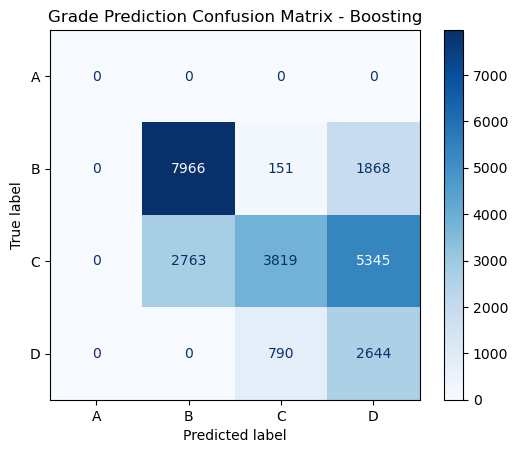

In [75]:
# Create a confusion matrix
cm_boost = confusion_matrix(y_test, y_pred_boost, labels = boost.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_boost, display_labels = boost.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title("Grade Prediction Confusion Matrix - Boosting")
plt.show()

#### Decision Tree

In [76]:
# fit decision tree model
tree = DecisionTreeClassifier(class_weight = 'balanced', random_state = 3)
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


Print a text summary of the decision tree.

In [77]:
tree_summary = export_text(tree, feature_names=X_train.columns.tolist())
print(tree_summary)

|--- pct_white <= 0.69
|   |--- pct_renter_severely_burdened <= 0.11
|   |   |--- Two races including Some Other Race <= 69.00
|   |   |   |--- 35.0 to 39.9 percent <= 4.00
|   |   |   |   |--- class: D
|   |   |   |--- 35.0 to 39.9 percent >  4.00
|   |   |   |   |--- pct_renter_occ <= 0.43
|   |   |   |   |   |--- class: B
|   |   |   |   |--- pct_renter_occ >  0.43
|   |   |   |   |   |--- class: B
|   |   |--- Two races including Some Other Race >  69.00
|   |   |   |--- pct_owner_occ <= 0.21
|   |   |   |   |--- class: C
|   |   |   |--- pct_owner_occ >  0.21
|   |   |   |   |--- class: C
|   |--- pct_renter_severely_burdened >  0.11
|   |   |--- pct_black <= 0.15
|   |   |   |--- Median value (dollars) <= 1032600.00
|   |   |   |   |--- 35.0 to 39.9 percent <= 117.50
|   |   |   |   |   |--- pct_owner_occ <= 0.24
|   |   |   |   |   |   |--- 20.0 to 24.9 percent <= 194.50
|   |   |   |   |   |   |   |--- SqFtTotLiving_is_missing <= 0.50
|   |   |   |   |   |   |   |   |--- class:

Find the importance of each feature.

In [78]:
importances = pd.DataFrame({'feature_name': X_train.columns, 'importance': tree.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

                    feature_name  importance
0                      pct_white    0.207411
1              pct_two_plus_race    0.158976
2   pct_renter_severely_burdened    0.114742
3           40.0 to 49.9 percent    0.088830
4                      pct_black    0.073185
..                           ...         ...
78                     pct_asian    0.000000
79               pct_pacific_isl    0.000000
80                pct_other_race    0.000000
81     NbrLivingUnits_is_missing    0.000000
82                 is_industrial    0.000000

[83 rows x 2 columns]


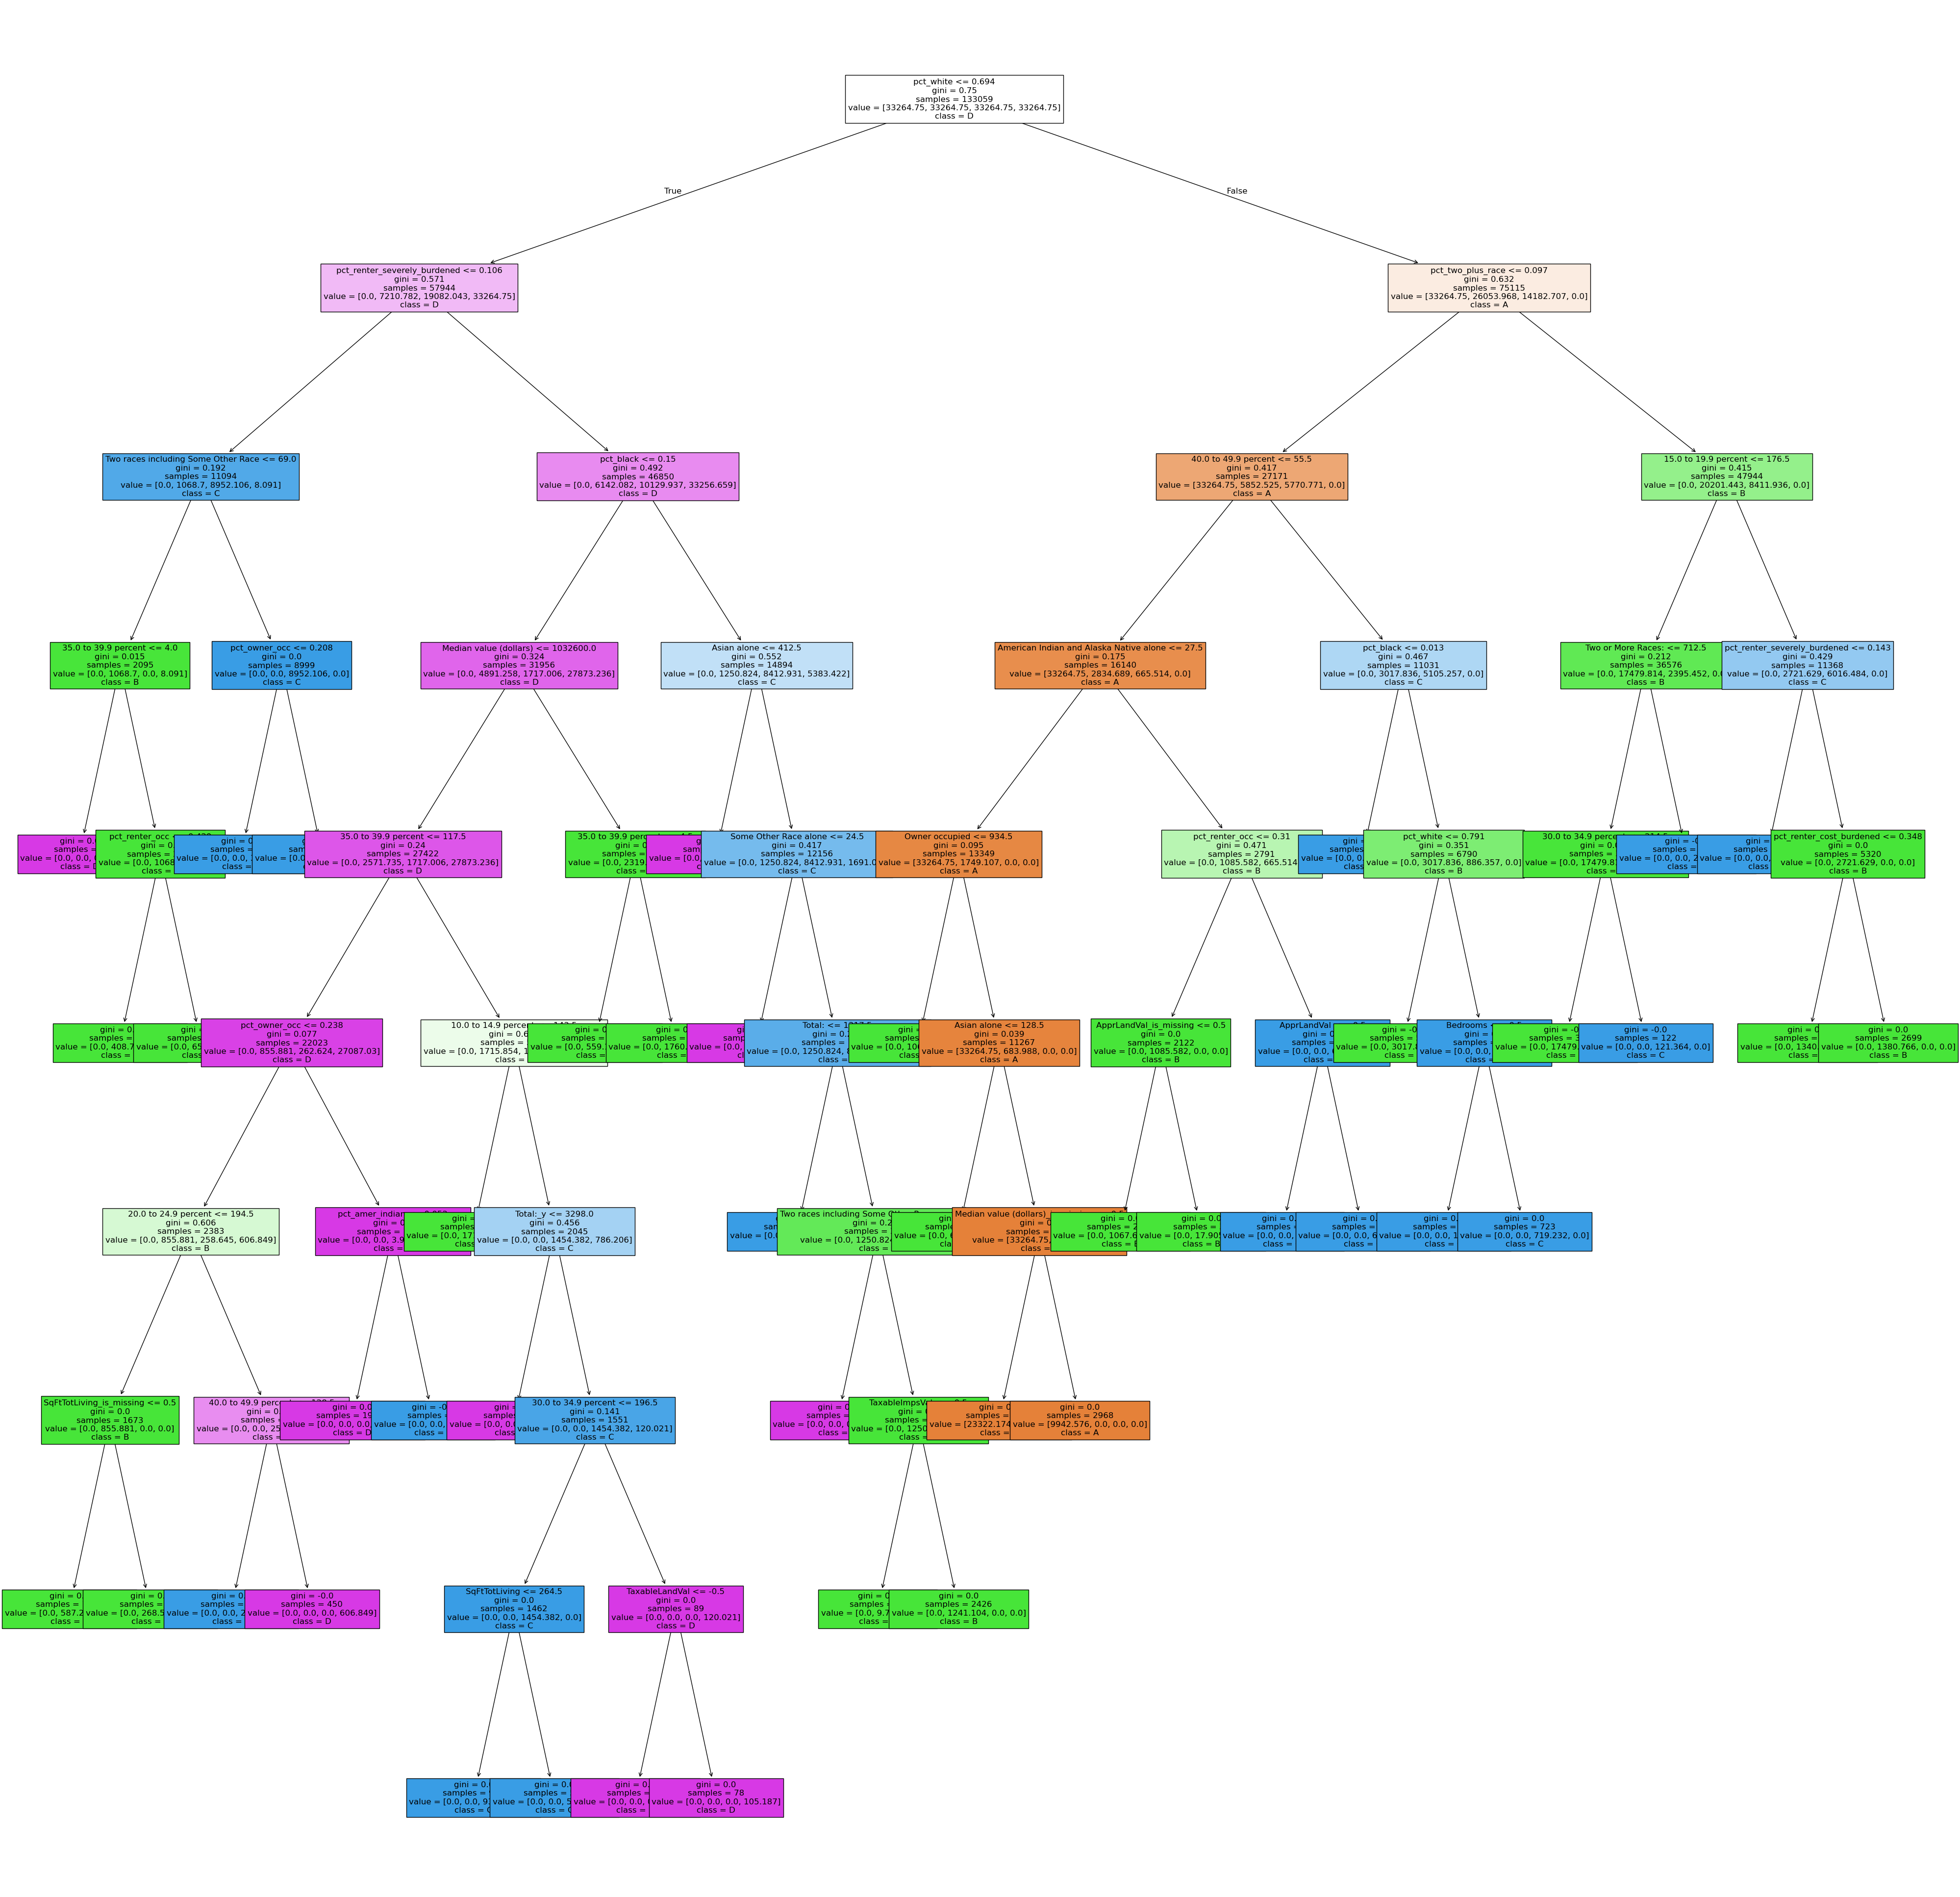

In [79]:
plt.figure(figsize=(50,50))
plot_tree(tree
          , filled=True
          , feature_names=X_train.columns
          , class_names=tree.classes_
          , label='all'
          , fontsize=12)
plt.show()

Create a confusion matrix.

In [80]:
# predict on test data
tree_pred = tree.predict(X_test)

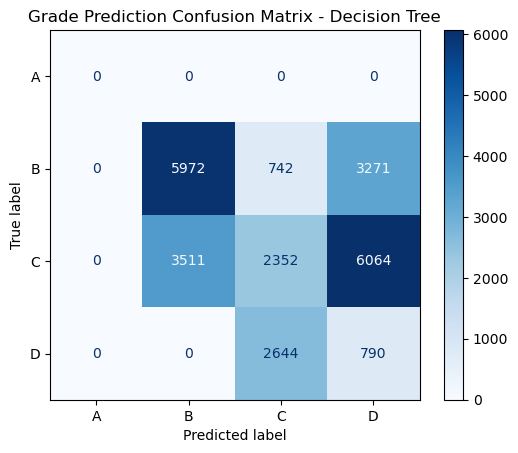

In [81]:
# Create a confusion matrix
cm_tree = confusion_matrix(y_test, tree_pred, labels = tree.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_tree, display_labels = tree.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title("Grade Prediction Confusion Matrix - Decision Tree")
plt.show()